# Extended Simulation Notebook — 5-Commodity Joint DGP

This notebook extends `simulated_data.ipynb` (2D: price + temperature) to a
**5-dimensional joint Gaussian DGP** covering five commodity/driver series:

| Index | Series | Base | σ | Intraday structure | Annual structure |
|-------|--------|------|---|-------------------|------------------|
| 0 | `price` (synthetic) | 50.0 | 5.0 | Strong (peak/off-peak) | Moderate |
| 1 | `temp` | 10.0 | 3.0 | Diurnal cycle | Strong seasonal |
| 2 | `elec_price` | 55.0 | 12.0 | Strong (higher vol) | Moderate |
| 3 | `gas` | 40.0 | 8.0 | Moderate | Moderate |
| 4 | `carbon` | 65.0 | 6.0 | None (policy-driven) | Low |

**Correlation structure (physically motivated):**
- price ↔ elec_price: ρ = 0.70 (both electricity-related)
- elec_price ↔ gas: ρ = 0.65 (gas sets marginal cost for power)
- price ↔ gas: ρ = 0.60 (common driver)
- price ↔ temp: ρ = 0.50 (heating/cooling demand, original)
- temp ↔ gas: ρ = 0.50 (heating demand)
- elec_price ↔ carbon: ρ = 0.40 (carbon cost pass-through)
- elec_price ↔ temp: ρ = 0.40 (temperature sensitivity)
- gas ↔ carbon: ρ = 0.35 (combustion emissions)
- price ↔ carbon: ρ = 0.30
- temp ↔ carbon: ρ = 0.20 (weakest link)

**Extension rationale:** Per industry partner guidance (Rikard Engström,
Energy Quant Solutions AB), the synthetic DGP is generalised to cover
additional commodity dimensions relevant to energy market risk management.
Real simulation outputs for these commodities are not available; the
synthetic approach preserves the controlled positive-control property
of the original notebook while extending framework scope.

**Parameters:** n_days = 365, n_paths = 5000, n_horizons = 8760 (hourly, 1 year)

In [7]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats
import pickle

print("Libraries loaded.")

Libraries loaded.


## 1. Setup

In [8]:
np.random.seed(42)

# ============================================================
# Simulation parameters
# ============================================================

n_days     = 365     # evaluation horizon (as-of dates)
n_paths    = 5000    # Monte Carlo paths per as-of date
n_horizons = 8760    # hourly steps (365 * 24)

asof_dates = pd.date_range("2020-01-01", periods=n_days, freq="D")
hours      = np.arange(1, n_horizons + 1)
path_cols  = [f"path_{i}" for i in range(1, n_paths + 1)]

# 5 series in order: price, temp, elec_price, gas, carbon
series_names = ["price", "temp", "elec_price", "gas", "carbon"]
N_SERIES = len(series_names)

print(f"n_days={n_days}, n_paths={n_paths}, n_horizons={n_horizons}")
print(f"Series: {series_names}")

n_days=365, n_paths=5000, n_horizons=8760
Series: ['price', 'temp', 'elec_price', 'gas', 'carbon']


## 2. DGP Parameters

### 2.1 Per-Series Marginal Parameters

In [9]:
# ============================================================
# Marginal DGP parameters per series
# Index order: [price, temp, elec_price, gas, carbon]
# ============================================================

# Base levels (unconditional mean)
base = np.array([50.0,  10.0,  55.0,  40.0,  65.0])

# Standard deviations
sigma = np.array([5.0,   3.0,  12.0,   8.0,   6.0])

# Intraday amplitude (peak-to-trough in €/MWh or °C)
# Carbon has no intraday structure (policy-driven, not demand-driven)
amp_day = np.array([10.0,  8.0,  14.0,   6.0,   0.0])

# Annual amplitude
# Carbon has weak annual structure
amp_year = np.array([5.0,  12.0,   6.0,   8.0,   2.0])

# Phase shift for intraday cycle (hour of peak)
# price/elec: peak around hour 18-19, gas: peak around hour 8 (morning heating)
# temp: peak around hour 14, carbon: no intraday
peak_hour = np.array([18.0,  14.0,  18.0,   8.0,   0.0])

# Annual phase shift: positive = winter peak, negative = summer peak
# price/elec/gas: winter peak (heating), temp: summer peak, carbon: slight winter
annual_phase_shift = np.array([0.0,  np.pi,  0.0,  0.0,  0.3])

# Intraday waveform mix: primary sine + harmonic
# [primary_weight, harmonic_weight] per series
# Carbon: no intraday, so both zero
intraday_mix = np.array([
    [0.8, 0.2],   # price
    [1.0, 0.0],   # temp (simple cosine)
    [0.8, 0.2],   # elec_price
    [0.7, 0.3],   # gas (morning hump)
    [0.0, 0.0],   # carbon (no intraday)
])

print("Marginal DGP parameters set.")
for i, s in enumerate(series_names):
    print(f"  {s:12s}  base={base[i]:5.1f}  sigma={sigma[i]:4.1f}  "
          f"amp_day={amp_day[i]:4.1f}  amp_year={amp_year[i]:4.1f}")

Marginal DGP parameters set.
  price         base= 50.0  sigma= 5.0  amp_day=10.0  amp_year= 5.0
  temp          base= 10.0  sigma= 3.0  amp_day= 8.0  amp_year=12.0
  elec_price    base= 55.0  sigma=12.0  amp_day=14.0  amp_year= 6.0
  gas           base= 40.0  sigma= 8.0  amp_day= 6.0  amp_year= 8.0
  carbon        base= 65.0  sigma= 6.0  amp_day= 0.0  amp_year= 2.0


### 2.2 Correlation Matrix and Cholesky Decomposition

In [10]:
# ============================================================
# 5x5 correlation matrix
# Order: [price, temp, elec_price, gas, carbon]
# ============================================================

rho_matrix = np.array([
#  price  temp  elec   gas  carbon
  [1.00,  0.50,  0.70,  0.60,  0.30],  # price
  [0.50,  1.00,  0.40,  0.50,  0.20],  # temp
  [0.70,  0.40,  1.00,  0.65,  0.40],  # elec_price
  [0.60,  0.50,  0.65,  1.00,  0.35],  # gas
  [0.30,  0.20,  0.40,  0.35,  1.00],  # carbon
])

# Verify positive definiteness
eigenvalues = np.linalg.eigvalsh(rho_matrix)
print(f"Correlation matrix eigenvalues: {np.round(eigenvalues, 4)}")
assert np.all(eigenvalues > 0), "Correlation matrix is not positive definite!"
print("Positive definite: OK")

# Build full covariance matrix: cov[i,j] = rho[i,j] * sigma[i] * sigma[j]
cov = rho_matrix * np.outer(sigma, sigma)

# Cholesky decomposition for correlated shock generation: cov = L @ L.T
L = np.linalg.cholesky(cov)
print(f"\nCovariance matrix shape: {cov.shape}")
print(f"Cholesky L shape: {L.shape}")
print("Cholesky decomposition: OK")

Correlation matrix eigenvalues: [0.2672 0.4003 0.5994 0.8342 2.8988]
Positive definite: OK

Covariance matrix shape: (5, 5)
Cholesky L shape: (5, 5)
Cholesky decomposition: OK


## 3. Hourly Mean Functions

Each series has an hourly mean that depends on hour-of-day and day-of-year.

In [11]:
def compute_hourly_means(dt_index: pd.DatetimeIndex) -> np.ndarray:
    """
    Compute the (n_horizons, N_SERIES) array of hourly conditional means.

    Parameters
    ----------
    dt_index : DatetimeIndex of length n_horizons

    Returns
    -------
    means : np.ndarray of shape (n_horizons, N_SERIES)
    """
    hod       = dt_index.hour.values          # 0..23
    doy       = dt_index.dayofyear.values     # 1..365
    day_phase = 2 * np.pi * hod / 24.0
    year_phase = 2 * np.pi * (doy - 1) / 365.0

    means = np.zeros((len(dt_index), N_SERIES))

    for i in range(N_SERIES):
        phase_shift = 2 * np.pi * peak_hour[i] / 24.0

        # Intraday component
        intraday = amp_day[i] * (
            intraday_mix[i, 0] * np.sin(day_phase - phase_shift) +
            intraday_mix[i, 1] * np.sin(2 * (day_phase - phase_shift))
        )

        # Annual component
        annual = amp_year[i] * np.cos(year_phase + annual_phase_shift[i])

        means[:, i] = base[i] + intraday + annual

    return means


# Quick sanity check on first as-of date
dt_test = pd.date_range(asof_dates[0], periods=n_horizons, freq="h")
means_test = compute_hourly_means(dt_test)
print("Hourly mean range check (first as-of date):")
for i, s in enumerate(series_names):
    print(f"  {s:12s}  min={means_test[:,i].min():.2f}  "
          f"max={means_test[:,i].max():.2f}  "
          f"mean={means_test[:,i].mean():.2f}")

Hourly mean range check (first as-of date):
  price         min=36.27  max=63.73  mean=50.00
  temp          min=-10.00  max=30.00  mean=10.00
  elec_price    min=36.78  max=73.22  mean=55.00
  gas           min=26.80  max=53.20  mean=40.00
  carbon        min=63.00  max=67.00  mean=65.00


## 4. Joint Simulation Loop

For each as-of date:
1. Compute hourly conditional means for all 5 series
2. Draw `n_paths` correlated shock paths: Z ~ N(0, I₅), eps = Z @ L.T
3. Store simulation paths in `sims_dict[asof][series_name]`
4. Draw one realisation per hour from the same DGP (well-specified positive control)

In [12]:
# ============================================================
# 4. Joint Simulation Loop — memory-efficient
# ============================================================
# For n_days=365 × n_paths=5000 × n_horizons=8760 × 5 series,
# storing full path DataFrames requires ~640 GB — not feasible.
# Instead we store:
#   sims_dict[asof][series] = {"lo": array(n_horizons,),
#                               "hi": array(n_horizons,),
#                               "yhat": array(n_horizons,)}
# Paths are processed in horizon-chunks to keep peak RAM < 200 MB.

ALPHA      = 0.10     # 90% central interval
CHUNK_SIZE = 500      # horizon steps per chunk (~100 MB peak per chunk)

sims_dict     = {}
realized_dict = {s: pd.DataFrame(index=asof_dates, columns=hours, dtype=float)
                 for s in series_names}

print(f"Simulating {n_days} as-of dates × {n_paths} paths × "
      f"{n_horizons} horizons × {N_SERIES} series...")
print(f"Memory mode: chunked (chunk_size={CHUNK_SIZE}), storing lo/hi only.\n")

for idx, asof in enumerate(asof_dates):
    dt_index = pd.date_range(asof, periods=n_horizons, freq="h")
    means    = compute_hourly_means(dt_index)   # (n_horizons, N_SERIES)

    # Allocate per-series lo/hi arrays for this as-of date
    lo_arr   = np.zeros((n_horizons, N_SERIES), dtype=np.float32)
    hi_arr   = np.zeros((n_horizons, N_SERIES), dtype=np.float32)

    # Process simulation paths in horizon chunks to limit peak memory
    for h_start in range(0, n_horizons, CHUNK_SIZE):
        h_end   = min(h_start + CHUNK_SIZE, n_horizons)
        n_chunk = h_end - h_start

        # Z: (n_chunk, n_paths, N_SERIES) — float32 halves memory vs float64
        Z   = np.random.normal(size=(n_chunk, n_paths, N_SERIES)).astype(np.float32)
        eps = Z @ L.T.astype(np.float32)                    # (n_chunk, n_paths, N_SERIES)
        sims_chunk = means[h_start:h_end, None, :].astype(np.float32) + eps

        # Store only empirical quantile bounds — discard full paths
        lo_arr[h_start:h_end] = np.quantile(sims_chunk, ALPHA / 2,       axis=1)
        hi_arr[h_start:h_end] = np.quantile(sims_chunk, 1 - ALPHA / 2,  axis=1)
        del Z, eps, sims_chunk   # free chunk memory immediately

    # Realized values: one draw per hour from same DGP
    Z_real   = np.random.normal(size=(n_horizons, N_SERIES))
    eps_real = Z_real @ L.T
    realized = means + eps_real   # (n_horizons, N_SERIES)

    # Store compact representation
    sims_dict[asof] = {}
    for i, s in enumerate(series_names):
        sims_dict[asof][s] = {
            "yhat": means[:, i].astype(np.float32),
            "lo":   lo_arr[:, i],
            "hi":   hi_arr[:, i],
        }
        realized_dict[s].loc[asof, :] = realized[:, i]

    if (idx + 1) % 50 == 0:
        print(f"  {idx+1}/{n_days} as-of dates completed")

print("Simulation complete.")

Simulating 365 as-of dates × 5000 paths × 8760 horizons × 5 series...
Memory mode: chunked (chunk_size=500), storing lo/hi only.

  50/365 as-of dates completed
  100/365 as-of dates completed
  150/365 as-of dates completed
  200/365 as-of dates completed
  250/365 as-of dates completed
  300/365 as-of dates completed
  350/365 as-of dates completed
Simulation complete.


## 5. Sanity Checks

In [13]:
# ── Check 1: yhat range should match base levels ─────────────────────────────
asof_check = asof_dates[0]
print("yhat range check (first as-of date):")
for s in series_names:
    yhat = sims_dict[asof_check][s]["yhat"]
    print(f"  {s:12s}  min={yhat.min():.2f}  max={yhat.max():.2f}  mean={yhat.mean():.2f}")

print()

# ── Check 2: Positive control — empirical coverage ~90% ──────────────────────
print(f"Positive control: empirical 90% coverage across {n_days} as-of dates")
for s in series_names:
    coverages = []
    for asof in asof_dates:
        lo       = sims_dict[asof][s]["lo"]
        hi       = sims_dict[asof][s]["hi"]
        realized_row = realized_dict[s].loc[asof].values.astype(float)
        coverages.append(np.mean((realized_row >= lo) & (realized_row <= hi)))
    print(f"  {s:12s}  avg coverage = {np.mean(coverages):.4f}  (nominal = 0.90)")

yhat range check (first as-of date):
  price         min=36.27  max=63.73  mean=50.00
  temp          min=-10.00  max=30.00  mean=10.00
  elec_price    min=36.78  max=73.22  mean=55.00
  gas           min=26.80  max=53.20  mean=40.00
  carbon        min=63.00  max=67.00  mean=65.00

Positive control: empirical 90% coverage across 365 as-of dates
  price         avg coverage = 0.8997  (nominal = 0.90)
  temp          avg coverage = 0.8997  (nominal = 0.90)
  elec_price    avg coverage = 0.8996  (nominal = 0.90)
  gas           avg coverage = 0.8998  (nominal = 0.90)
  carbon        avg coverage = 0.8997  (nominal = 0.90)


In [15]:
# ── Check 1: yhat range should match base levels ─────────────────────────────
asof_check = asof_dates[0]
print("yhat range check (first as-of date):")
for s in series_names:
    yhat = sims_dict[asof_check][s]["yhat"]
    print(f"  {s:12s}  min={yhat.min():.2f}  max={yhat.max():.2f}  mean={yhat.mean():.2f}")

print()

# ── Check 2: Positive control — empirical coverage ~90% ──────────────────────
print(f"Positive control: empirical 90% coverage across {n_days} as-of dates")
print("(lo/hi computed during simulation from 5000 paths per chunk)")

for s in series_names:
    coverages = []
    for asof in asof_dates:
        lo           = sims_dict[asof][s]["lo"]
        hi           = sims_dict[asof][s]["hi"]
        realized_row = realized_dict[s].loc[asof].values.astype(float)
        coverages.append(np.mean((realized_row >= lo) & (realized_row <= hi)))
    print(f"  {s:12s}  avg coverage = {np.mean(coverages):.4f}  (nominal = 0.90)")

print()

# ── Check 3: Cross-series correlation (yhat at first horizon step) ────────────
print("Cross-series yhat correlation check (first horizon step across all as-of dates):")
yhat_mat = np.vstack([
    [sims_dict[asof][s]["yhat"][0] for asof in asof_dates]
    for s in series_names
])  # (N_SERIES, n_days)
emp_corr = np.corrcoef(yhat_mat)
print(pd.DataFrame(emp_corr, index=series_names, columns=series_names).round(2))
print("\nNote: yhat correlation reflects seasonal mean structure, not path correlation.")

yhat range check (first as-of date):
  price         min=36.27  max=63.73  mean=50.00
  temp          min=-10.00  max=30.00  mean=10.00
  elec_price    min=36.78  max=73.22  mean=55.00
  gas           min=26.80  max=53.20  mean=40.00
  carbon        min=63.00  max=67.00  mean=65.00

Positive control: empirical 90% coverage across 365 as-of dates
(lo/hi computed during simulation from 5000 paths per chunk)
  price         avg coverage = 0.8997  (nominal = 0.90)
  temp          avg coverage = 0.8997  (nominal = 0.90)
  elec_price    avg coverage = 0.8996  (nominal = 0.90)
  gas           avg coverage = 0.8998  (nominal = 0.90)
  carbon        avg coverage = 0.8997  (nominal = 0.90)

Cross-series yhat correlation check (first horizon step across all as-of dates):
            price  temp  elec_price   gas  carbon
price        1.00 -1.00        1.00  1.00    0.96
temp        -1.00  1.00       -1.00 -1.00   -0.96
elec_price   1.00 -1.00        1.00  1.00    0.96
gas          1.00 -1.00      

## 6. Visualisation — Seasonal Structure

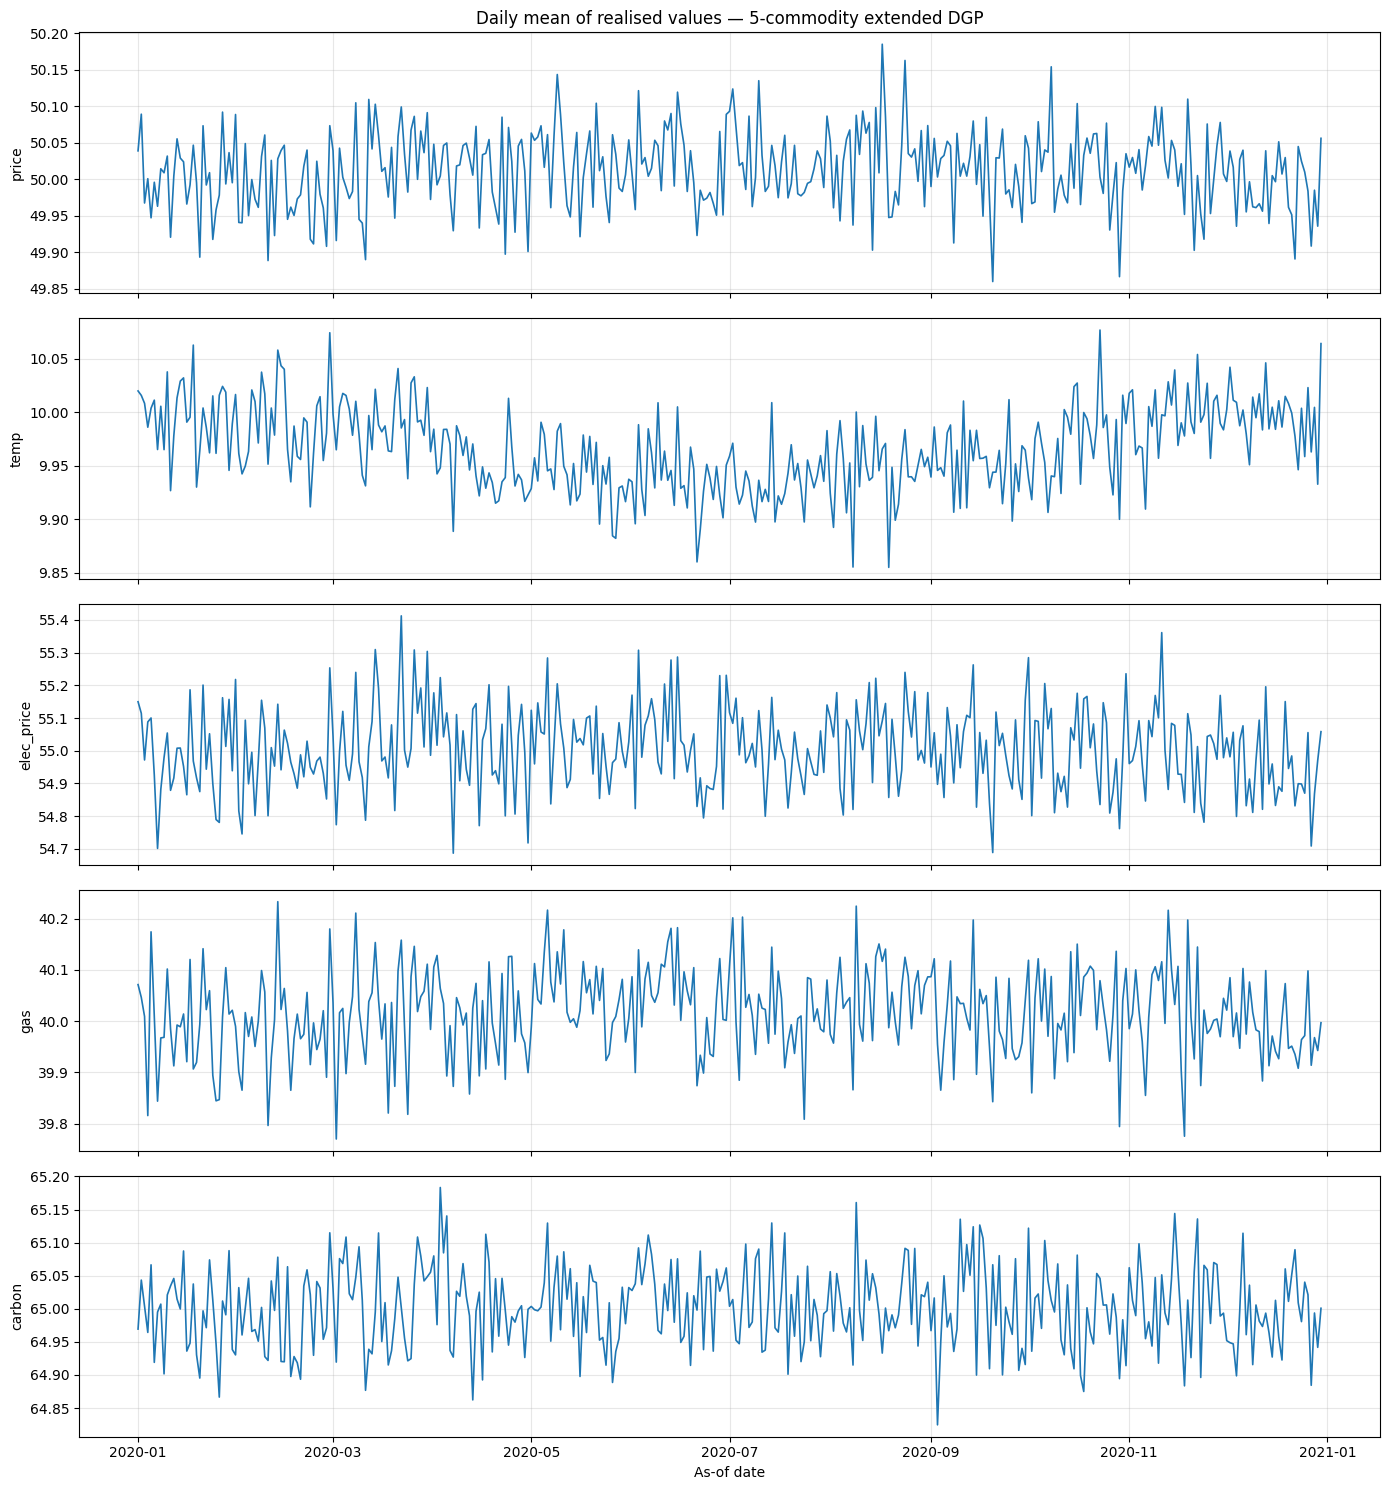

In [16]:
# Plot daily mean of each realised series across the year
fig, axes = plt.subplots(N_SERIES, 1, figsize=(14, 3 * N_SERIES), sharex=True)

for i, s in enumerate(series_names):
    # Daily mean of realised values
    daily_means = [
        realized_dict[s].loc[asof].values.astype(float).mean()
        for asof in asof_dates
    ]
    axes[i].plot(asof_dates, daily_means, lw=1.2)
    axes[i].set_ylabel(s, fontsize=10)
    axes[i].grid(alpha=0.3)

axes[0].set_title("Daily mean of realised values — 5-commodity extended DGP", fontsize=12)
axes[-1].set_xlabel("As-of date")
plt.tight_layout()
plt.show()

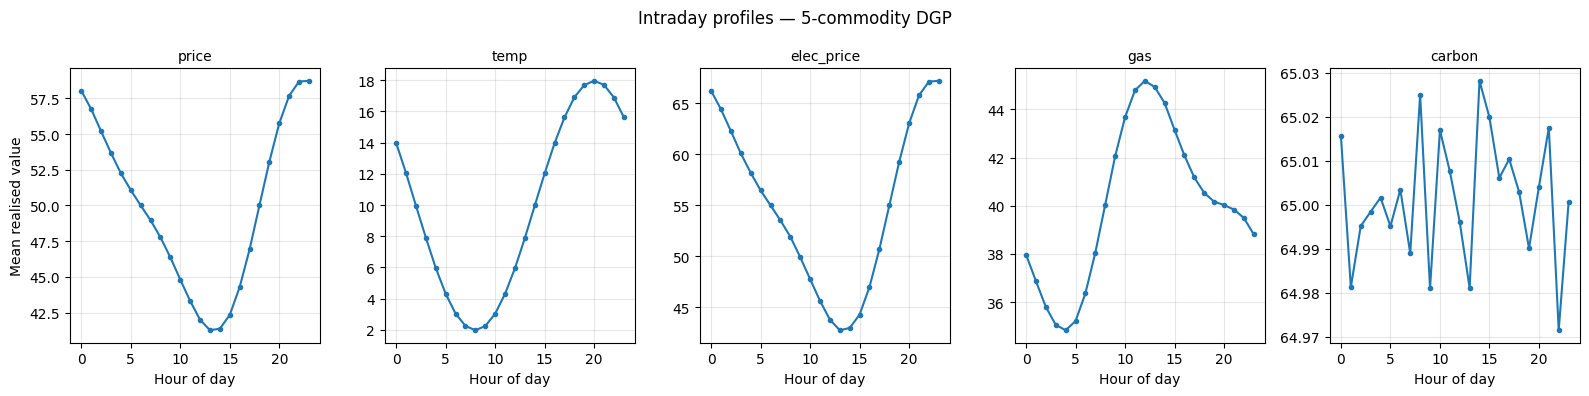

In [17]:
# Plot mean intraday profile for each series (averaged across all as-of dates)
fig, axes = plt.subplots(1, N_SERIES, figsize=(16, 4))

for i, s in enumerate(series_names):
    # Mean realised value per hour-of-day across all as-of dates
    hod_means = np.zeros(24)
    for asof in asof_dates:
        vals = realized_dict[s].loc[asof].values.astype(float)  # 8760
        for h in range(24):
            hod_means[h] += vals[h::24].mean()
    hod_means /= n_days
    axes[i].plot(range(24), hod_means, marker='o', ms=3)
    axes[i].set_title(s, fontsize=10)
    axes[i].set_xlabel("Hour of day")
    axes[i].grid(alpha=0.3)

axes[0].set_ylabel("Mean realised value")
fig.suptitle("Intraday profiles — 5-commodity DGP", fontsize=12)
plt.tight_layout()
plt.show()

## 7. Save and Reload

In [21]:
from pathlib import Path
output_path = Path().resolve().parent / "data" / "sims_dict_extended.pkl"
with open(output_path, "wb") as f:
     pickle.dump({
         "sims_dict":     sims_dict,
         "realized_dict": realized_dict,
         "series_names":  series_names,
         "asof_dates":    asof_dates,
         "rho_matrix":    rho_matrix,
         "sigma":         sigma,
         "base":          base,
     }, f, protocol=pickle.HIGHEST_PROTOCOL)
print(f"Saved to {output_path}")

Saved to C:\Users\jiaya\OneDrive\Documents\Lund_2025\Thesis\unified-probabilistic-validation\data\sims_dict_extended.pkl


In [28]:
import glob, os
results = glob.glob(r"C:\Users\jiaya\**\sims_dict_extended.pkl", recursive=True)
print(results)

['C:\\Users\\jiaya\\OneDrive\\Documents\\Lund_2025\\Thesis\\unified-probabilistic-validation\\data\\sims_dict_extended.pkl']


In [30]:
from pathlib import Path

pkl_path = Path(r"C:\Users\jiaya\OneDrive\Documents\Lund_2025\Thesis\unified-probabilistic-validation\data\sims_dict_extended.pkl")

with open(pkl_path, "rb") as f:
    saved = pickle.load(f)

sims_dict     = saved["sims_dict"]
realized_dict = saved["realized_dict"]
series_names  = saved["series_names"]
print("Loaded successfully.")

Loaded successfully.


## 8. Example Output

In [31]:
# Example: lo/hi bounds for electricity price, first as-of date
asof_ex = asof_dates[0]
print("elec_price — first 5 horizon steps:")
print(f"  yhat: {sims_dict[asof_ex]['elec_price']['yhat'][:5]}")
print(f"  lo:   {sims_dict[asof_ex]['elec_price']['lo'][:5]}")
print(f"  hi:   {sims_dict[asof_ex]['elec_price']['hi'][:5]}")

print("\ncarbon — first 5 horizon steps:")
print(f"  yhat: {sims_dict[asof_ex]['carbon']['yhat'][:5]}")
print(f"  lo:   {sims_dict[asof_ex]['carbon']['lo'][:5]}")
print(f"  hi:   {sims_dict[asof_ex]['carbon']['hi'][:5]}")

elec_price — first 5 horizon steps:
  yhat: [72.2      70.418365 68.27461  66.1196   64.175125]
  lo:   [52.104004 50.053917 49.1573   46.079674 44.50313 ]
  hi:   [92.02056 90.31517 88.24582 85.97872 83.91727]

carbon — first 5 horizon steps:
  yhat: [66.910675 66.910675 66.910675 66.910675 66.910675]
  lo:   [57.22411 56.89917 56.97574 56.99087 57.09209]
  hi:   [76.58254  76.72392  76.546585 76.925964 76.615715]
